# KANVAS, Phase 3: Regularized Training and an Honest Benchmark

[Phase 2](02_alibaba_pipeline_eda.ipynb) trained KANVAS on 2,310 tasks from Alibaba's PAI GPU cluster and left two problems on the table:

1. **Curves that swing where there is no data.** Some $\varphi_i$ curves had large peaks and dips over stretches of the x-axis with almost no training tasks, for example `plan_cpu` +2.5 near 1,400 and `plan_gpu` −2.7 near 150. Those swings are fitting noise, not findings.
2. **No stopping rule.** Training ran a fixed 1,000 epochs. The held-out loss bottomed out around epoch 114 and then crept up, so the model kept fitting noise for almost 900 more epochs.

This notebook fixes both **in the training loop only**. `BSplineEdge` and `KAAM` are used exactly as they are, including their forward passes and additive structure. The data is Phase 2's exact feature matrix, loaded from disk rather than rebuilt.

### The benchmark protocol

Every number in this notebook comes from one of three disjoint slices of the data. Each slice has one job.

| Split | Share | Used for |
|---|---|---|
| train | 70% | fitting weights, and the min-max scaling ranges |
| validation | 15% | early stopping, choosing the penalty strength λ, tuning the decision threshold |
| test | 15% | **only** the final report in section 6, opened once after every choice is frozen |

If the test set influenced any choice, its numbers would be optimistic by construction. Keeping it sealed until the end is what makes this an *honest* benchmark.

**Roadmap:** load the data → (1) smoothness penalty → (2) split → (3) early stopping → (4) λ sweep → (5) threshold tuning → (6) test report → (7) final curves vs. Phase 2.

In [1]:
import inspect
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from cycler import cycler
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MaxNLocator
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from kanvas.data import FEATURE_NAMES, scale_features
from kanvas.model import KAAM
from kanvas.training import (classification_metrics, predict_proba, smoothness_penalty, train_kaam,
                             train_val_test_split, tune_threshold)
from kanvas.utils import set_seed

%matplotlib inline
pd.set_option("display.width", 200)

# Chart style (same as Phase 2): light surface, hairline grid, ink-toned text.
SURFACE, INK, INK_2, MUTED, BASELINE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#c3c2b7"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
LAMBDA_RAMP = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]  # one hue, light -> dark as λ grows
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlecolor": INK, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": BASELINE, "ytick.color": BASELINE, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.prop_cycle": cycler(color=[BLUE, ORANGE]), "lines.linewidth": 1.5,
    "legend.frameon": False, "font.size": 10,
})

FEATURE_UNITS = {
    "plan_cpu": "CPU requested (100 = 1 core)",
    "plan_mem": "memory requested (GB)",
    "plan_gpu": "GPU requested (100 = 1 GPU)",
    "inst_num": "instances requested",
    "avg_cpu_usr": "node user CPU (%)",
    "avg_gpu_util": "node GPU util, summed over GPUs (%)",
    "avg_cpu_kernel": "node kernel CPU (%)",
    "avg_load_1": "node 1-min load average",
    "cap_gpu": "GPUs installed on node",
    "avg_net_receive": "node network receive (trace units)",
}


def compact(value):
    # Tick label with M/G suffixes so network rates stay readable.
    for divisor, suffix in ((1e9, "G"), (1e6, "M")):
        if abs(value) >= divisor:
            return f"{value / divisor:g}{suffix}"
    return f"{value:,.4g}"


def centered_curve(model, name, feature_ranges, X_ref, num_points=300):
    # phi over the feature's range in raw units, shifted so its mean over X_ref's tasks is 0.
    # (A constant can move freely between a curve and the bias, so only the shape carries meaning.)
    lo, hi = feature_ranges[name]
    edge = model.edges[name]
    xs, ys = edge.get_curve(num_points)
    with torch.no_grad():
        offset = edge(torch.tensor(((X_ref[name] - lo) / (hi - lo)).to_numpy(np.float32))).mean().item()
    return lo + xs * (hi - lo), ys - offset


def bootstrap_auc_ci(y_true, p, n_boot=2000, seed=0):
    # 95% percentile interval for ROC-AUC, resampling tasks with replacement.
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if y_true[idx].min() != y_true[idx].max():
            aucs.append(roc_auc_score(y_true[idx], p[idx]))
    return np.percentile(aucs, [2.5, 97.5])


def paired_bootstrap_auc_diff(y_true, p_a, p_b, n_boot=2000, seed=0):
    # 95% interval for AUC(p_a) - AUC(p_b), resampling the same tasks for both models.
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if y_true[idx].min() != y_true[idx].max():
            diffs.append(roc_auc_score(y_true[idx], p_a[idx]) - roc_auc_score(y_true[idx], p_b[idx]))
    return np.percentile(diffs, [2.5, 97.5])

## 0. Load Phase 2's feature matrix

No joins are re-run here: `data/processed/kanvas_features.csv` is the exact 2,310-task matrix Phase 2 produced. We check that it is the matrix we think it is before using it.

In [2]:
df = pd.read_csv("../data/processed/kanvas_features.csv", index_col=["job_name", "task_name"])
X, y = df[FEATURE_NAMES], df["label"]

assert X.shape == (2310, 10) and list(X.columns) == FEATURE_NAMES
assert int(y.sum()) == 646 and set(y.unique()) == {0, 1}
print(f"{len(X):,} tasks, {int(y.sum())} failed ({y.mean():.2%}), {X.shape[1]} features, no NaNs: {not X.isna().any().any()}")

2,310 tasks, 646 failed (27.97%), 10 features, no NaNs: True


## 1. Step 1: a smoothness penalty on the spline coefficients

Each feature's curve is $\varphi(x) = w_{\text{base}}\,\text{SiLU}(x) + \sum_i c_i B_i(x)$: a smooth base term plus a weighted sum of 14 bump-shaped B-spline basis functions, one per point of a uniform knot grid. The coefficients $c_i$ set the height of each bump, so **how jagged the curve is depends entirely on how jagged the coefficient sequence is**.

The penalty is the P-spline idea (Eilers & Marx, 1996): sum the squared *second differences* of neighbouring coefficients, over every edge,

$$P = \sum_{\text{features}} \sum_i \big(c_{i+1} - 2c_i + c_{i-1}\big)^2 ,$$

and train on $\text{BCE} + \lambda \cdot P$.

- A straight run of coefficients has zero second difference and costs nothing, so **slopes are free** and only bends are charged.
- A bend is kept only if the data pays for it with a lower BCE. Where no training tasks sit under part of the grid, nothing pays, and the curve relaxes toward a straight line. That is exactly what should happen over the empty stretches that produced Phase 2's spikes.
- λ sets the exchange rate. λ = 0 is Phase 2's plain BCE; a very large λ forces every spline toward a straight line.

The penalty touches only the spline coefficients. It is a term in the loss, not a change to the model.

In [3]:
print(inspect.getsource(smoothness_penalty))

second_diff = lambda c: c[2:] - 2 * c[1:-1] + c[:-2]
straight = 0.1 * torch.arange(14.0)
bent = straight.clone()
bent[7] += 1.0
print(f"penalty for a straight coefficient line:  {(second_diff(straight) ** 2).sum().item():.1f}")
print(f"penalty after bending one coefficient:    {(second_diff(bent) ** 2).sum().item():.1f}   (second differences +1, -2, +1)")

def smoothness_penalty(model):
    """Sum of squared second differences of every edge's spline coefficients.

    On a uniform knot grid, ``c[i+1] - 2*c[i] + c[i-1]`` measures how sharply
    the curve bends at that point of the grid (the P-spline penalty of Eilers
    & Marx, 1996). A straight run of coefficients costs nothing, so slopes
    are free and only curvature is charged; the data has to justify every
    bend. Where no training tasks sit under part of the grid, nothing
    justifies a bend, and the curve stays close to straight there.

    Only spline coefficients are penalized: each edge's SiLU base weight and
    the model bias are left free.

    Args:
        model: A KAAM whose ``edges`` ModuleDict holds BSplineEdge modules.

    Returns:
        0-dim tensor, differentiable with respect to the coefficients.
    """
    total = torch.zeros(())
    for edge in model.edges.values():
        coef = edge.spline_weight
        second_diff = coef[2:] - 2 * coef[1:-1] + coef[:

## 2. Step 2: a 70 / 15 / 15 train / validation / test split

The split is stratified on the label, so all three parts keep the 28% failure rate, and it is seeded (`random_state=42`) so every run sees the same tasks.

One refinement over Phase 2: the min-max scaling ranges are now fitted on the **training split only**, inside `train_kaam`. In Phase 2 they came from all 2,310 tasks, so a sliver of test information reached the model through the scaling. (Phase 2's 1st/99th-percentile clipping was fitted on all rows too. That lives in the frozen data pipeline and isn't redone here; at those percentiles its effect is negligible.)

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(X, y, val_size=0.15, test_size=0.15, random_state=42)

for name, part in (("train", y_train), ("validation", y_val), ("test", y_test)):
    print(f"{name:<11s} {len(part):>5,} tasks  failure rate {part.mean():.2%}")
assert not set(X_test.index) & (set(X_train.index) | set(X_val.index)) and not set(X_train.index) & set(X_val.index)

train       1,616 tasks  failure rate 27.97%
validation    347 tasks  failure rate 27.95%
test          347 tasks  failure rate 27.95%


## 3. Step 3: early stopping on validation loss

`train_kaam` keeps the Phase 2 loop (full-batch Adam, lr = 0.01, one step per epoch) and adds two things:

- **The loss is $\text{BCE} + \lambda P$** on the training split.
- **After every epoch it measures plain BCE on the validation split.** That is the quantity we actually want to be low on unseen tasks, so the penalty is left out of it. When validation loss hasn't improved for `patience = 15` consecutive epochs, training stops.

The model then **reloads the weights from its best validation epoch**, not the last one. The last 15 epochs are by definition the ones where the model got worse on unseen data. Stopping late and keeping the late weights would be the Phase 2 problem again, just shorter.

Progress prints every 20 epochs as `train loss (BCE + lambda*penalty)` and `val loss`, and each run ends with a line saying which epoch triggered the stop and which epoch's weights were restored.

## 4. Step 4: the λ sweep, an ablation

Four models, identical in everything except λ ∈ {0, 0.001, 0.01, 0.1}: same split, same seed (so the same starting weights), same patience, same 500-epoch cap.

For each we record:
- the best and stopping epochs;
- validation BCE at the restored weights and at the stopping epoch;
- validation AUC and accuracy;
- **roughness**, the unweighted penalty $P$ at the restored weights, which measures how bent the curves ended up.

**The choice of λ uses only these validation numbers and the curve shapes below.** Test columns for this table are filled in once, in section 6.

In [5]:
LAMBDAS = [0.0, 0.001, 0.01, 0.1]
UNIT_RANGES = {name: (0.0, 1.0) for name in FEATURE_NAMES}  # train_kaam scales every input to [0, 1]
models, results, rows = {}, {}, []

for lam in LAMBDAS:
    print(f"\n=== lambda_smooth = {lam:g} ===")
    set_seed(42)
    model = KAAM(FEATURE_NAMES, UNIT_RANGES, num_knots=10, spline_order=3)
    result = train_kaam(model, X_train, y_train, X_val, y_val, lambda_smooth=lam, patience=15, max_epochs=500)
    val = classification_metrics(y_val, predict_proba(model, X_val, result.feature_ranges), threshold=0.5)
    models[lam], results[lam] = model, result
    rows.append({
        "lambda": lam, "best epoch": result.best_epoch, "stopped at": result.stopped_epoch,
        "val BCE (restored)": result.best_val_loss, "val BCE at stop": result.history["val_loss"][-1],
        "val AUC": val["auc"], "val acc @0.5": val["accuracy"], "roughness P": smoothness_penalty(model).item(),
    })

val_table = pd.DataFrame(rows).set_index("lambda")
print("\n" + val_table.round(4).to_string())


=== lambda_smooth = 0 ===


Epoch   20  train loss 0.5402 (BCE 0.5402 + lambda*penalty 0.0000)  val loss 0.5361


Epoch   40  train loss 0.5054 (BCE 0.5054 + lambda*penalty 0.0000)  val loss 0.5063


Epoch   60  train loss 0.4891 (BCE 0.4891 + lambda*penalty 0.0000)  val loss 0.4954


Epoch   80  train loss 0.4781 (BCE 0.4781 + lambda*penalty 0.0000)  val loss 0.4898


...

Epoch  320  train loss 0.5009 (BCE 0.4921 + lambda*penalty 0.0088)  val loss 0.4959


Epoch  340  train loss 0.5003 (BCE 0.4913 + lambda*penalty 0.0090)  val loss 0.4957


Epoch  360  train loss 0.4998 (BCE 0.4906 + lambda*penalty 0.0092)  val loss 0.4957


Epoch  380  train loss 0.4994 (BCE 0.4900 + lambda*penalty 0.0094)  val loss 0.4957


Early stopping triggered at epoch 391: val loss has not improved for 15 epochs. Restored weights from epoch 376 (val loss 0.4957).

        best epoch  stopped at  val BCE (restored)  val BCE at stop  val AUC  val acc @0.5  roughness P
lambda                                                                                                 
0.000          121         136              0.4867           0.4870   0.7638        0.7954      69.0045
0.001          167         182              0.4868           0.4868   0.7606        0.7954       5.3566
0.010          175         190              0.4889           0.4889   0.7520        0.7983       0.4922
0.100          376         391              0.4957           0.4957   0.7381        0.7983       0.0938


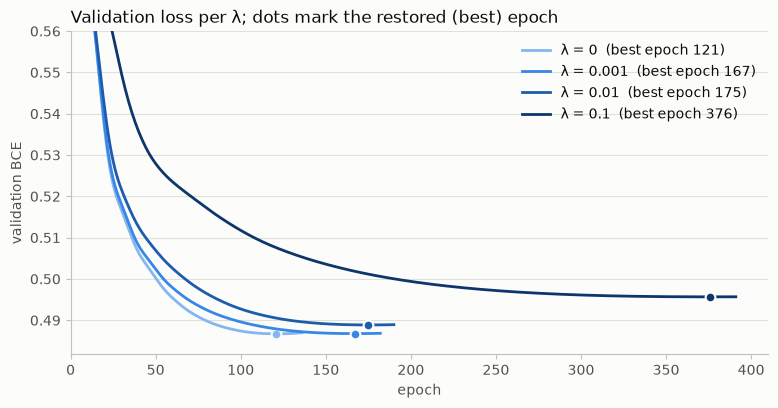

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.2))
for color, lam in zip(LAMBDA_RAMP, LAMBDAS):
    val_loss, best = results[lam].history["val_loss"], results[lam].best_epoch
    ax.plot(range(1, len(val_loss) + 1), val_loss, color=color, lw=2, label=f"λ = {lam:g}  (best epoch {best})")
    ax.plot(best, val_loss[best - 1], "o", color=color, ms=7, mec=SURFACE, mew=1.5)
ax.set_ylim(min(r.best_val_loss for r in results.values()) - 0.005, 0.56)
ax.set_xlim(0, 410)
ax.set_xlabel("epoch")
ax.set_ylabel("validation BCE")
ax.grid(axis="y")
ax.legend(loc="upper right")
ax.set_title("Validation loss per λ; dots mark the restored (best) epoch", loc="left")
plt.show()

### The curves behind the numbers

Rows are the four features with Phase 2's worst artifacts, and columns are λ from 0 to 0.1.

- Each curve is shifted so its average over the training tasks is 0. The curve's absolute level trades off freely against the model's bias, so only the shape carries meaning.
- The y-axis is **shared across each row**, so flattening is visible as a curve shrinks toward zero.
- Tick marks along the bottom show where training tasks actually sit. Curve segments with no ticks under them are shaped by the penalty, not by data.

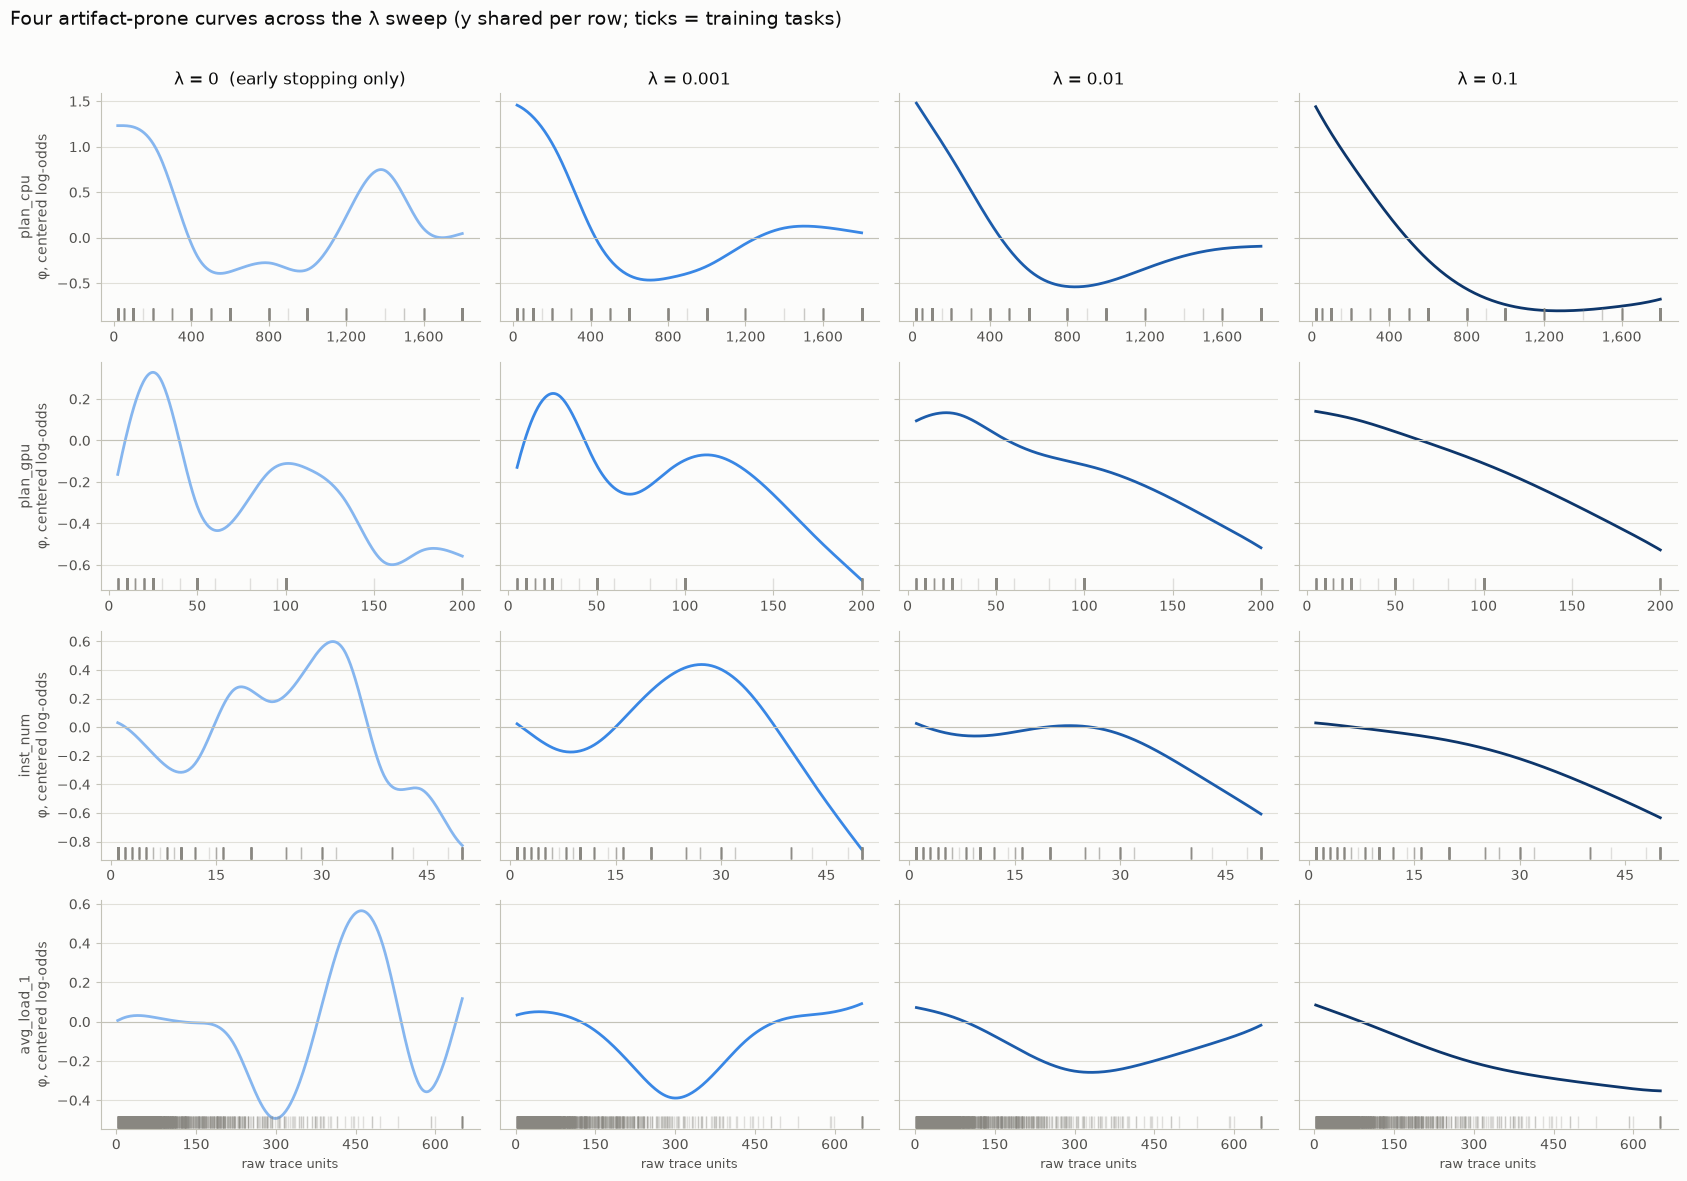

In [7]:
SWEEP_FEATURES = ["plan_cpu", "plan_gpu", "inst_num", "avg_load_1"]
fig, axes = plt.subplots(len(SWEEP_FEATURES), len(LAMBDAS), figsize=(17, 12), sharey="row")
for r, name in enumerate(SWEEP_FEATURES):
    for c, lam in enumerate(LAMBDAS):
        ax = axes[r, c]
        x_raw, phi = centered_curve(models[lam], name, results[lam].feature_ranges, X_train)
        ax.plot(x_raw, phi, color=LAMBDA_RAMP[c], lw=2)
        ax.axhline(0, color=BASELINE, lw=0.8)
        ax.plot(X_train[name], np.full(len(X_train), 0.03), "|", color=MUTED, alpha=0.25, ms=9,
                transform=ax.get_xaxis_transform())
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: compact(v)))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.grid(axis="y")
        if r == 0:
            ax.set_title(f"λ = {lam:g}" + ("  (early stopping only)" if lam == 0 else ""), fontsize=12)
        if c == 0:
            ax.set_ylabel(f"{name}\nφ, centered log-odds", fontsize=10)
        if r == len(SWEEP_FEATURES) - 1:
            ax.set_xlabel("raw trace units", fontsize=9)
fig.suptitle("Four artifact-prone curves across the λ sweep (y shared per row; ticks = training tasks)",
             x=0.01, ha="left", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

**Reading the sweep (validation only).**

**Predictive performance: the penalty buys smoothness, not accuracy.**
- Validation BCE: λ = 0 and λ = 0.001 are tied (0.4867 vs 0.4868), λ = 0.01 is slightly worse (0.4889), and λ = 0.1 is clearly worse (0.4957).
- Validation AUC drifts down in the same order: 0.764, 0.761, 0.752, 0.738.
- With about 97 failures in the validation split, AUC differences of a few thousandths are noise, but the direction is consistent.

**Early stopping alone (λ = 0) already avoids Phase 2's most extreme swings**, because training stops at epoch 121 instead of 1,000. It still leaves artifacts wherever training data is thin:
- a +0.74 bump in `plan_cpu` near 1,400, with only 3 training tasks between 1,200 and 1,600;
- a −0.60 dip in `plan_gpu` near 160, with 1 training task between 100 and 200;
- a +0.57 / −0.35 swing in `avg_load_1` above 450, with 23 tasks;
- a −0.52 dip in `plan_mem` near 47 GB.

**λ = 0.001 removes all of them:**
- `plan_cpu` at 1,400 sits at +0.11 on a smooth rise;
- `plan_gpu` falls steadily from 100 to 200;
- `avg_load_1` recovers smoothly above 300;
- `plan_mem` at 47 GB is −0.05.

Roughness drops 13× (69 → 5.4), while the dense-region shapes survive. Tasks requesting up to 1 core (308 training tasks, 71% failed) sit at +1.3 to +1.5, vs −0.4 at the common 6-core request (1,012 tasks, 17% failed).

**λ = 0.01 starts erasing real signal.** The clearest dense-region contrast in the data is `plan_gpu`: 457 training tasks request 25 (45.7% failed) and 210 request 50 (11.0% failed). The curve's 25-vs-50 gap is 0.65 log-odds at λ = 0, 0.35 at 0.001, and only **0.10 at 0.01**.

In exchange, λ = 0.01 flattens two thinly supported bumps that 0.001 keeps:
- `inst_num` around 27, with 65 training tasks between 20 and 35;
- `avg_cpu_kernel` around 29, with 74 tasks above 25%.

**λ = 0.1 over-flattens.** Nearly every curve is a straight or gently bent line, and validation loss is clearly worse.

**Recommendation: λ = 0.001.** It is the smallest penalty that removes the sparse-region artifacts, at no measurable validation cost, and it keeps the best-supported shapes in the model. Its two soft spots (`inst_num` near 27, `avg_cpu_kernel` near 29) sit over thin data; read them with the rug.

**The final choice is yours:** change `CHOSEN_LAMBDA` below and re-run from there. Decide *before* reading section 6, though. A λ picked after seeing test numbers turns the test set into a second validation set.

In [8]:
CHOSEN_LAMBDA = 0.001  # chosen from validation metrics + curve shapes above; the test set has not been used yet
final_model, final_result = models[CHOSEN_LAMBDA], results[CHOSEN_LAMBDA]
print(f"chosen lambda = {CHOSEN_LAMBDA}  (restored epoch {final_result.best_epoch}, "
      f"val BCE {final_result.best_val_loss:.4f})")

chosen lambda = 0.001  (restored epoch 167, val BCE 0.4868)


## 5. Step 5: tuning the decision threshold on validation data

Phase 2 flagged a task as risky when its predicted probability passed **0.5**. That is a convention, not a decision. Depending on how the model's probabilities are spread, the best trade-off between catching failures and raising false alarms can sit above or below it.

Instead we sweep thresholds from 0.10 to 0.90 in steps of 0.05 on the **validation** split. At each one we compute:
- **precision**: of the tasks we flag, how many really fail;
- **recall**: of the tasks that fail, how many we flag;
- **F1**: the harmonic mean of the two.

We keep the threshold with the best F1.

`tune_threshold` takes only validation labels and probabilities. Its signature has no parameter through which test data could arrive, and a unit test enforces that.

In [9]:
p_val = predict_proba(final_model, X_val, final_result.feature_ranges)
best_threshold, threshold_table = tune_threshold(y_val, p_val)

print(threshold_table.round(3).to_string(index=False))
row = threshold_table.set_index("threshold").loc[best_threshold]
print(f"\nF1-maximizing threshold on validation: {best_threshold:.2f}  "
      f"(precision {row['precision']:.3f}, recall {row['recall']:.3f}, F1 {row['f1']:.3f})")

 threshold  precision  recall    f1
      0.10      0.310   0.969 0.470
      0.15      0.364   0.928 0.523
      0.20      0.385   0.814 0.523
      0.25      0.467   0.649 0.543
      0.30      0.543   0.515 0.529
      0.35      0.610   0.485 0.540
      0.40      0.639   0.474 0.544
      0.45      0.672   0.464 0.549
      0.50      0.703   0.464 0.559
      0.55      0.714   0.464 0.562
      0.60      0.759   0.454 0.568
      0.65      0.784   0.412 0.541
      0.70      0.923   0.247 0.390
      0.75        NaN   0.000 0.000
      0.80        NaN   0.000 0.000
      0.85        NaN   0.000 0.000
      0.90        NaN   0.000 0.000

F1-maximizing threshold on validation: 0.60  (precision 0.759, recall 0.454, F1 0.568)


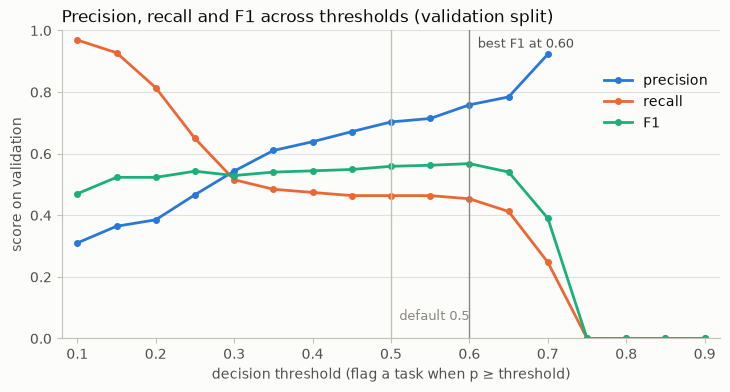

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4))
for column, color in (("precision", BLUE), ("recall", ORANGE), ("f1", AQUA)):
    ax.plot(threshold_table["threshold"], threshold_table[column], color=color, lw=2, marker="o", ms=4,
            label=column if column != "f1" else "F1")
ax.axvline(best_threshold, color=MUTED, lw=1)
ax.annotate(f"best F1 at {best_threshold:.2f}", (best_threshold, 0.98), xytext=(6, 0), textcoords="offset points",
            color=INK_2, fontsize=9, va="top")
ax.axvline(0.5, color=BASELINE, lw=1)
ax.annotate("default 0.5", (0.5, 0.06), xytext=(6, 0), textcoords="offset points", color=MUTED, fontsize=9)
ax.set_xlim(0.08, 0.92)
ax.set_ylim(0, 1)
ax.set_xlabel("decision threshold (flag a task when p ≥ threshold)")
ax.set_ylabel("score on validation")
ax.grid(axis="y")
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.9))
ax.set_title("Precision, recall and F1 across thresholds (validation split)", loc="left")
plt.show()

**Reading the threshold sweep.**

Validation F1 is almost flat, between 0.52 and 0.57, for every threshold from 0.15 to 0.65. The maximum lands at **0.60** (F1 0.568, precision 0.759, recall 0.454), just above the default 0.5 (F1 0.559).

What moves between 0.5 and 0.6 is precision, not recall:
- raising the threshold drops a few false alarms (precision 0.703 → 0.759);
- it loses almost no failures (recall 0.464 → 0.454), because the failures this model catches mostly score well above 0.6.

Above 0.70 the model flags no validation task at all, so precision is undefined (NaN) and its line stops.

**How much to trust 0.60: not much.** A 0.009 F1 edge over 0.5 on 347 validation tasks is well within noise, and any threshold from 0.25 to 0.60 is statistically indistinguishable. We keep 0.60 because the procedure says maximize F1, and section 6 shows whether its edge survives on the test set.

If this model drove alerts, a recall target would be a more meaningful rule than F1, for example "catch 80% of failures". On validation that means a threshold near 0.20, at a precision of about 0.39.

## 6. Step 6: the test set, opened once

Everything is frozen now:
- λ = `CHOSEN_LAMBDA`, picked in section 4;
- the weights, restored by early stopping on validation;
- the threshold, picked in section 5.

The cell below is **the only place in this notebook that reads `X_test` or `y_test`**. It produces two things:

1. **The completed ablation table.** For all four λ models, including the ones we didn't pick, so the paper can report the ablation honestly:
   - test AUC, with a 95% bootstrap interval over test tasks;
   - test accuracy at 0.5;
   - each model's AUC difference from λ = 0, with a *paired* bootstrap interval. Both models are scored on the same resampled tasks, which is the right test for "does the penalty change AUC?"
2. **The final model's metrics at the default 0.5 threshold and at the tuned threshold, side by side.** That keeps the effect of threshold tuning explicit.

In [11]:
# ---- the single test-set evaluation ----
test_probs = {lam: predict_proba(models[lam], X_test, results[lam].feature_ranges) for lam in LAMBDAS}

ablation = val_table[["best epoch", "val BCE (restored)", "val AUC", "roughness P"]].copy()
for lam in LAMBDAS:
    m = classification_metrics(y_test, test_probs[lam], threshold=0.5)
    lo, hi = bootstrap_auc_ci(y_test, test_probs[lam])
    ablation.loc[lam, "test AUC"] = m["auc"]
    ablation.loc[lam, "test AUC 95% CI"] = f"[{lo:.3f}, {hi:.3f}]"
    ablation.loc[lam, "test acc @0.5"] = m["accuracy"]
    if lam == 0.0:
        ablation.loc[lam, "test AUC minus λ=0 [paired 95% CI]"] = "(reference)"
    else:
        d_lo, d_hi = paired_bootstrap_auc_diff(y_test, test_probs[lam], test_probs[0.0])
        ablation.loc[lam, "test AUC minus λ=0 [paired 95% CI]"] = (
            f"{m['auc'] - ablation.loc[0.0, 'test AUC']:+.3f} [{d_lo:+.3f}, {d_hi:+.3f}]")
print("Ablation: lambda_smooth sweep (selection used validation columns only)\n")
print(ablation.round(4).to_string())

p_test = test_probs[CHOSEN_LAMBDA]
at_default = classification_metrics(y_test, p_test, threshold=0.5)
at_tuned = classification_metrics(y_test, p_test, threshold=best_threshold)
side_by_side = pd.DataFrame({"threshold 0.5 (default)": at_default,
                             f"threshold {best_threshold:.2f} (tuned on val)": at_tuned}).drop("threshold")
print(f"\nFinal model (lambda = {CHOSEN_LAMBDA}) on the test set, {len(y_test)} tasks, {int(y_test.sum())} failures:\n")
print(side_by_side.loc[["accuracy", "auc", "precision", "recall", "f1"]].astype(float).round(4).to_string())
print(f"\nMajority-class baseline accuracy (always predict Terminated): {1 - y_test.mean():.4f}")

for label, m in (("0.5 (default)", at_default), (f"{best_threshold:.2f} (tuned)", at_tuned)):
    cm = pd.DataFrame([[m["tn"], m["fp"]], [m["fn"], m["tp"]]], index=["actual Terminated", "actual Failed"],
                      columns=["pred Terminated", "pred Failed"])
    print(f"\nConfusion matrix, threshold {label}:\n{cm.to_string()}")

Ablation: lambda_smooth sweep (selection used validation columns only)

        best epoch  val BCE (restored)  val AUC  roughness P  test AUC test AUC 95% CI  test acc @0.5 test AUC minus λ=0 [paired 95% CI]
lambda                                                                                                                                  
0.000          121              0.4867   0.7638      69.0045    0.7277  [0.666, 0.788]         0.7896                        (reference)
0.001          167              0.4868   0.7606       5.3566    0.7169  [0.652, 0.776]         0.7867            -0.011 [-0.026, +0.004]
0.010          175              0.4889   0.7520       0.4922    0.7118  [0.648, 0.771]         0.7867            -0.016 [-0.042, +0.009]
0.100          376              0.4957   0.7381       0.0938    0.7077  [0.642, 0.767]         0.7839            -0.020 [-0.054, +0.011]

Final model (lambda = 0.001) on the test set, 347 tasks, 97 failures:

           threshold 0.5 (default)

**Reading the test results.** These are the numbers to quote. Every choice behind them was frozen before this cell ran.

**The ablation: regularization did not improve AUC.**
- Test AUC falls slightly as λ grows: 0.728 at λ = 0 (early stopping only), 0.717 at 0.001, 0.712 at 0.01, 0.708 at 0.1.
- The paired intervals, where both models are scored on the same resampled tasks, all include zero. For the chosen λ = 0.001 the difference is −0.011 [−0.026, +0.004].
- So the penalty's effect on AUC is not distinguishable from noise. If anything it costs a little, and it certainly doesn't buy more than a few thousandths.
- Test accuracy at 0.5 tells the same story: 0.790, 0.787, 0.787, 0.784.

**Plainly: on this data, the smoothness penalty does not improve predictive performance.** What it buys is curves that can be trusted where they are read (section 7), at an AUC cost of about 0.01 that is within noise. If the only goal were ranking tasks by risk, early stopping alone would do.

**Threshold tuning did not help on test either.** Moving from 0.50 to the validation-chosen 0.60:
- catches 2 fewer failures (39 → 37 of 97; recall 0.402 → 0.381);
- raises 3 fewer false alarms (16 → 13; precision 0.709 → 0.740);
- lowers F1 from 0.513 to 0.503, while accuracy ticks up from 0.787 to 0.790 (one more task classified correctly).

That is the flat validation F1 curve showing through: the "optimal" threshold was picked from noise, and its small validation edge did not transfer.

**Overall, the final model is a modest risk ranker.**
- Test AUC is 0.717 [0.652, 0.776].
- Accuracy is 0.787–0.790 against a 0.721 baseline of always predicting Terminated.
- At either threshold it catches about 2 in 5 failures, and 71–74% of its flags are real failures.

(Phase 2 reported AUC 0.719 on a different 20% split, so the two numbers are not directly comparable.)

## 7. The final curves, and what changed since Phase 2

To compare shapes fairly we need Phase 2's curves, so the next cell **re-trains Phase 2's exact recipe**:
- 80/20 split with `random_state=42`;
- scaling ranges from all rows;
- `set_seed(42)`;
- 1,000 epochs of plain BCE.

Training is deterministic, so this reproduces Phase 2's model. It is used **only as a drawing reference**: no metric is computed from it, and nothing in sections 4–6 depended on it.

In [12]:
phase2_ranges = {name: (float(X[name].min()), float(X[name].max())) for name in FEATURE_NAMES}
X_tr2, _, y_tr2, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
set_seed(42)
phase2_model = KAAM(FEATURE_NAMES, UNIT_RANGES, num_knots=10, spline_order=3)
x_tr2 = torch.tensor(scale_features(X_tr2, phase2_ranges).to_numpy(np.float32))
t_tr2 = torch.tensor(y_tr2.to_numpy(np.float32))
optimizer, loss_fn = torch.optim.Adam(phase2_model.parameters(), lr=0.01), torch.nn.BCELoss()
for epoch in range(1000):
    optimizer.zero_grad()
    loss = loss_fn(phase2_model(x_tr2), t_tr2)
    loss.backward()
    optimizer.step()
print(f"Phase 2 recipe reproduced: final train BCE {loss.item():.4f} (Phase 2 notebook reported 0.4435)")
print(f"roughness P: Phase 2 model {smoothness_penalty(phase2_model).item():.1f}  vs  final model "
      f"{smoothness_penalty(final_model).item():.1f}")

Phase 2 recipe reproduced: final train BCE 0.4435 (Phase 2 notebook reported 0.4435)
roughness P: Phase 2 model 2413.7  vs  final model 5.4


Below is `plot_all_curves()` for the final model, with the x-axes relabelled in raw trace units and training-task ticks along the bottom. The thin gray line is Phase 2's curve for the same feature, shifted to the same average level so the two shapes can be compared directly.

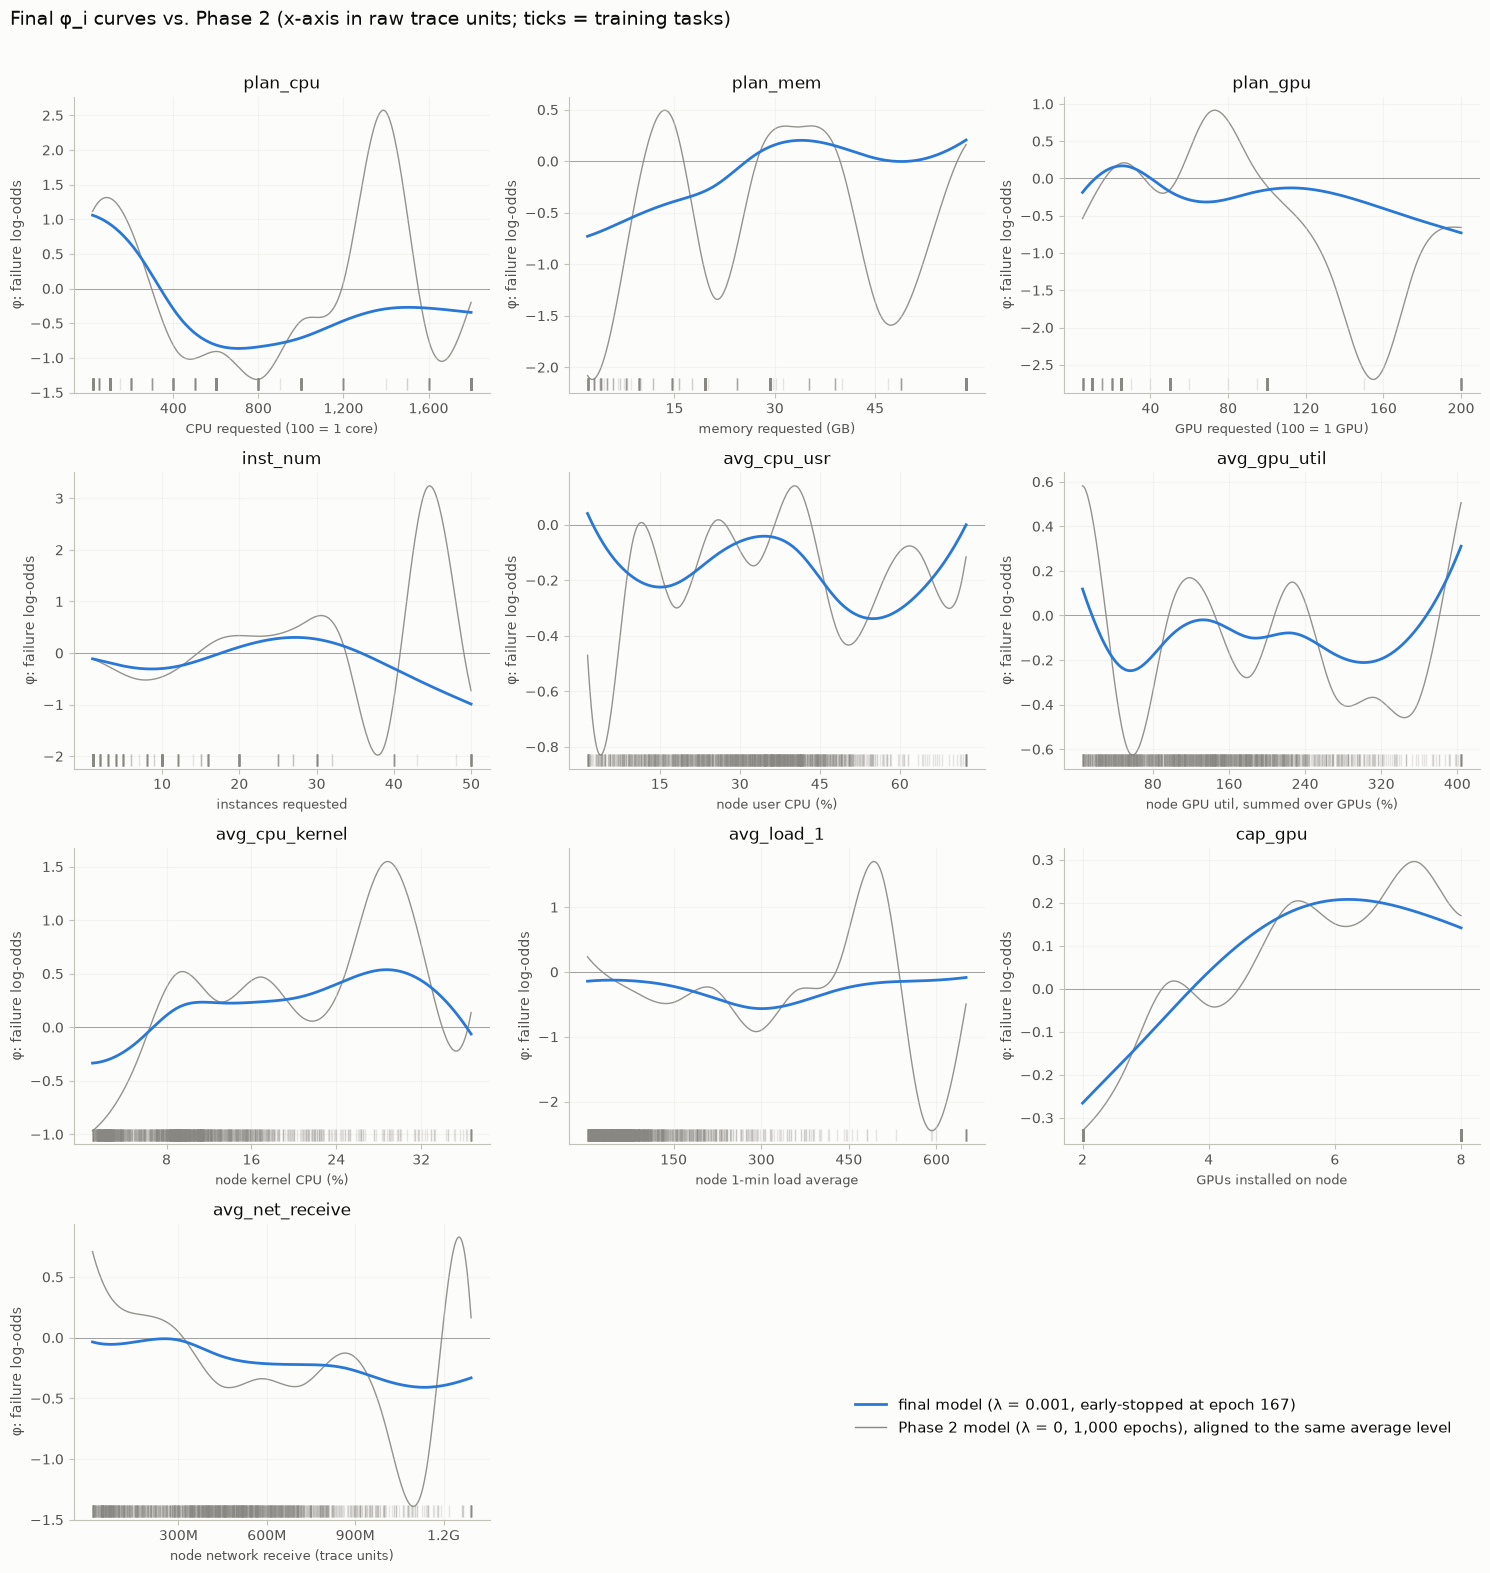

In [13]:
fig = final_model.plot_all_curves()
ranges = final_result.feature_ranges
for ax, name in zip(fig.axes, FEATURE_NAMES):
    lo, hi = ranges[name]
    edge3, edge2 = final_model.edges[name], phase2_model.edges[name]
    xs, ys = edge3.get_curve(300)
    lo2, hi2 = phase2_ranges[name]
    with torch.no_grad():
        ys2 = edge2(torch.tensor(((lo + xs * (hi - lo)) - lo2) / (hi2 - lo2), dtype=torch.float32)).numpy()
        train3 = torch.tensor(((X_train[name] - lo) / (hi - lo)).to_numpy(np.float32))
        train2 = torch.tensor(((X_train[name] - lo2) / (hi2 - lo2)).to_numpy(np.float32))
        shift = edge3(train3).mean().item() - edge2(train2).mean().item()
    ax.plot(xs, ys2 + shift, color=MUTED, lw=1, alpha=0.9, zorder=1)
    ax.lines[0].set_zorder(3)
    ax.lines[0].set_linewidth(2)

    raw_ticks = MaxNLocator(nbins=5, integer=True).tick_values(lo, hi)
    raw_ticks = raw_ticks[(raw_ticks >= lo) & (raw_ticks <= hi)]
    ax.set_xticks((raw_ticks - lo) / (hi - lo))
    ax.set_xticklabels([compact(t) for t in raw_ticks])
    ax.set_xlabel(FEATURE_UNITS[name], fontsize=9)
    ax.set_ylabel("φ: failure log-odds")
    ax.plot((X_train[name] - lo) / (hi - lo), np.full(len(X_train), 0.03), "|", color=MUTED, alpha=0.2, ms=9,
            transform=ax.get_xaxis_transform())

handles = [Line2D([], [], color=BLUE, lw=2, label=f"final model (λ = {CHOSEN_LAMBDA:g}, early-stopped at epoch {final_result.best_epoch})"),
           Line2D([], [], color=MUTED, lw=1, label="Phase 2 model (λ = 0, 1,000 epochs), aligned to the same average level")]
fig.legend(handles=handles, loc="lower right", bbox_to_anchor=(0.98, 0.08), fontsize=11)
fig.suptitle("Final φ_i curves vs. Phase 2 (x-axis in raw trace units; ticks = training tasks)",
             x=0.01, ha="left", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

**What changed since Phase 2.** Gray is Phase 2 and blue is the final model; values are read on the figure's scale. Every curve changed. The question is whether each one lost an artifact or lost signal.

**Artifacts removed, and the shape where the data sits is kept:**
- **`plan_cpu`.** Phase 2's +2.55 spike at 1,400 (3 training tasks between 1,200 and 1,600) is now −0.29 on a smooth, shallow rise. The real contrast survives: small requests at +0.93 to +1.06 vs −0.86 at 700.
- **`plan_gpu`.** The −2.70 dip at 155 (1 training task between 100 and 200) and the +0.88 bump at 70 are gone; the curve now falls steadily to −0.73 at 200. The 25-vs-50 contrast is fully kept (+0.17 vs −0.18, where Phase 2 had +0.20 vs −0.15). A mild ~0.15 ripple between 50 and 110 remains.
- **`inst_num`.** The +3.12 spike at 44 and −1.98 dip at 38 are gone. What's left is a gentle hump near 27 (+0.30) and a steady decline to −0.99 at 50.
- **`avg_load_1`.** The +1.70 / −2.40 swing at 490–600 (23 training tasks above 450) is gone. The curve is now nearly flat with a shallow dip near 300, and its total span shrank from 4.16 to 0.48 log-odds.
- **`plan_mem`.** Phase 2 swung between request sizes (+0.48 at 13 GB, −1.33 at 21 GB, −1.59 at 47 GB). The final curve rises smoothly from −0.73 at 2 GB to about +0.2 above 30 GB.
- **`avg_net_receive`.** The −1.39 dip at 1.1G and the +0.83 spike at 1.25G, both at the sparse top end, are gone. What remains is a gentle decline: higher recent network receive, slightly lower risk.

**Kept, but smaller:**
- **`avg_cpu_kernel`.** The rise from an idle node to ~9% kernel CPU is still there but smaller (−0.33 → +0.18, where Phase 2 went −0.97 → +0.50). The peak near 29% shrank from +1.55 to +0.54 without disappearing. It sits over 74 training tasks, so read it cautiously.
- **`avg_cpu_usr` and `avg_gpu_util`.** Their ripples across the dense range shrank to between a quarter and a third of Phase 2's (spans 0.92 → 0.30 and 0.97 → 0.23). What remains is small next to the request features: on their own, a node's recent user-CPU and GPU utilization carry little signal.

**Essentially unchanged:**
- **`cap_gpu`.** The 8-vs-2-GPU contrast is +0.41 (Phase 2: +0.50). With data only at 2 and 8 GPUs, the line between them is just interpolation.

## Summary: what Phase 3 did, and didn't, achieve

| Question | Answer |
|---|---|
| Does early stopping work? | **Yes.** All four runs stopped on their own (epochs 136–391) and restored their best-validation weights. On its own it avoided Phase 2's most extreme spikes. |
| Does the smoothness penalty remove the artifacts? | **Yes.** At λ = 0.001 every named sparse-region artifact is gone, curve roughness is 5.4 (the Phase 2 model: 2,414), and the dense-region contrasts survive. |
| Does regularization improve AUC? | **No.** Test AUC is 0.717 for λ = 0.001 vs 0.728 for early stopping alone. The difference, −0.011 [−0.026, +0.004], is not distinguishable from zero. The penalty's value is interpretability, not accuracy. |
| Does threshold tuning help? | **No.** Validation picked 0.60 off an almost flat F1 curve; on test, F1 went from 0.513 to 0.503 and precision from 0.709 to 0.740. |
| Final model | λ = 0.001, restored from epoch 167, test AUC 0.717 [0.652, 0.776], accuracy 0.787 at 0.5 and 0.790 at 0.60 (baseline 0.721) |

**What would move the numbers:**
- **More data.** 2,310 tasks give test intervals about 0.12 wide, and the pipeline's `sample_n_tasks` scales this directly.
- **A recall target instead of max-F1**, if the model is going to drive alerts.
- **Fewer knots for the discrete request features**, whose curves are only ever read at a handful of values.